# Installing packages for this Data Analysis, all may not be used, but install several just in case

In [56]:
install.packages("ggplot2")
install.packages("tidyverse")
install.packages("dplyr")
install.packages("readr")
install.packages("readxl")
install.packages("plyr")
install.packages("stringr")
install.packages("ggmap")
install.packages("biglm")
install.packages("data.table")
library(ggplot2)
library(tidyverse)
library(plyr)
library(dplyr)
library(readr)
library(readxl)
library(stringr)
library(ggmap)
library(biglm)
library(data.table)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# reading in all the csv files for the previous 12 months of data as data tables due to the size

In [57]:
Divvy_24_Feb <- fread("202402-divvy-tripdata.csv")
Divvy_24_Mar <- fread("202403-divvy-tripdata.csv")
Divvy_24_Apr <- fread("202404-divvy-tripdata.csv")
Divvy_24_May <- fread("202405-divvy-tripdata.csv")
Divvy_24_Jun <- fread("202406-divvy-tripdata.csv")
Divvy_24_Jul <- fread("202407-divvy-tripdata.csv")
Divvy_24_Aug <- fread("202408-divvy-tripdata.csv")
Divvy_24_Sep <- fread("202409-divvy-tripdata.csv")
Divvy_24_Oct <- fread("202410-divvy-tripdata.csv")
Divvy_24_Nov <- fread("202411-divvy-tripdata.csv")
Divvy_24_Dec <- fread("202412-divvy-tripdata.csv")
Divvy_25_Jan <- fread("202501-divvy-tripdata.csv")
Divvy_25_Feb <- fread("202502-divvy-tripdata.csv")

Warning message in fread("202406-divvy-tripdata.csv"):
“Discarded single-line footer: <<"5119746F85C8FFDA","classic_bike","2024-06-21 23:29:43.998","2024-06-21 23:52:27.275","Morgan St & Lake St*","chargingstx4","Halsted St & Wrightwood Ave","TA130900006>>”
Warning message in fread("202407-divvy-tripdata.csv"):
“Discarded single-line footer: <<"A55E2DFDAC4634BD","electric_bike","2024-07-14 22:02:36.904","2024-07-14 22:22:16.993","Clark St & Armitage Ave","13146","Clark St & Berwyn Ave","KA1504000146",41.918306,-8>>”
Warning message in fread("202408-divvy-tripdata.csv"):
“Discarded single-line footer: <<"A5F2C05D19CB7E83","classic_bike","2024-08-10 16>>”
Warning message in fread("202409-divvy-tripdata.csv"):
“Discarded single-line footer: <<"114A61EF1BEF7F56","classic_bike",>>”


# efficient loop that verifies the colnames of each data.table without typing out each individual name.

In [58]:
months <- c("Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec")
years <- c(rep(24, 11), 25, 25) # 24 for Feb-Dec, 25 for Jan-Feb

for (i in 1:length(months)) {
  df_name <- paste0("Divvy_", years[i], "_", months[i])
  if (exists(df_name)) { # Check if the data frame exists
    print(colnames(get(df_name)))
  } else {
    print(paste("Data frame", df_name, "does not exist."))
  }
}

 [1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"     
 [1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"     
 [1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"     
 [1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_stati

# combining all the dataframes into one dataframe

In [59]:
Divvy_24_25 <- rbind(Divvy_24_Feb, Divvy_24_Mar, Divvy_24_Apr, Divvy_24_May, Divvy_24_Jun, Divvy_24_Jul, Divvy_24_Aug, Divvy_24_Sep, Divvy_24_Oct, Divvy_24_Nov, Divvy_24_Dec, Divvy_25_Jan, Divvy_25_Feb)

# inspecting the data

In [60]:
head(Divvy_24_25)
str(Divvy_24_25)
summary(Divvy_24_25)
missing_coords <- which(is.na(Divvy_24_25$end_lat))
summary(missing_coords)

ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
<chr>,<chr>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
FCB05EB1758F85E8,classic_bike,2024-02-03 14:14:18,2024-02-03 14:21:00,Clark St & Newport St,632,Southport Ave & Waveland Ave,13235,41.94454,-87.65468,41.94815,-87.66394,member
7FB986AD5D3DE9D6,classic_bike,2024-02-05 21:10:06,2024-02-05 21:15:44,Michigan Ave & Washington St,13001,Wabash Ave & Grand Ave,TA1307000117,41.88398,-87.62468,41.89147,-87.62676,member
40CA13E15B5B470D,electric_bike,2024-02-05 15:10:44,2024-02-05 15:12:32,Leavitt St & Armitage Ave,TA1309000029,Milwaukee Ave & Wabansia Ave,13243,41.91760,-87.68250,41.91262,-87.68139,member
D47A1660919E8861,classic_bike,2024-02-15 12:40:34,2024-02-15 12:44:24,Southport Ave & Waveland Ave,13235,Southport Ave & Belmont Ave,13229,41.94815,-87.66394,41.93948,-87.66375,member
4CD173D11BA019F8,classic_bike,2024-02-14 12:28:36,2024-02-14 12:36:59,Wentworth Ave & 35th St,KA1503000005,Shields Ave & 31st St,KA1503000038,41.83078,-87.63250,41.83846,-87.63541,casual
DA5032C0CA737AF5,electric_bike,2024-02-16 00:54:48,2024-02-16 01:01:47,Sheridan Rd & Lawrence Ave,TA1309000041,Clark St & Newport St,632,41.96942,-87.65479,41.94454,-87.65468,member


Classes ‘data.table’ and 'data.frame':	4330167 obs. of  13 variables:
 $ ride_id           : chr  "FCB05EB1758F85E8" "7FB986AD5D3DE9D6" "40CA13E15B5B470D" "D47A1660919E8861" ...
 $ rideable_type     : chr  "classic_bike" "classic_bike" "electric_bike" "classic_bike" ...
 $ started_at        : POSIXct, format: "2024-02-03 14:14:18" "2024-02-05 21:10:06" ...
 $ ended_at          : POSIXct, format: "2024-02-03 14:21:00" "2024-02-05 21:15:44" ...
 $ start_station_name: chr  "Clark St & Newport St" "Michigan Ave & Washington St" "Leavitt St & Armitage Ave" "Southport Ave & Waveland Ave" ...
 $ start_station_id  : chr  "632" "13001" "TA1309000029" "13235" ...
 $ end_station_name  : chr  "Southport Ave & Waveland Ave" "Wabash Ave & Grand Ave" "Milwaukee Ave & Wabansia Ave" "Southport Ave & Belmont Ave" ...
 $ end_station_id    : chr  "13235" "TA1307000117" "13243" "13229" ...
 $ start_lat         : num  41.9 41.9 41.9 41.9 41.8 ...
 $ start_lng         : num  -87.7 -87.6 -87.7 -87.7 -87.6 ...

   ride_id          rideable_type        started_at                    
 Length:4330167     Length:4330167     Min.   :2024-02-01 00:01:50.00  
 Class :character   Class :character   1st Qu.:2024-05-08 17:41:08.00  
 Mode  :character   Mode  :character   Median :2024-07-19 15:21:24.01  
                                       Mean   :2024-07-22 21:06:23.50  
                                       3rd Qu.:2024-09-18 20:43:06.03  
                                       Max.   :2025-02-28 23:56:08.92  
                                                                       
    ended_at                      start_station_name start_station_id  
 Min.   :2024-02-01 00:08:07.00   Length:4330167     Length:4330167    
 1st Qu.:2024-05-08 17:57:46.00   Class :character   Class :character  
 Median :2024-07-19 15:39:04.67   Mode  :character   Mode  :character  
 Mean   :2024-07-22 21:22:54.65                                        
 3rd Qu.:2024-09-18 20:57:22.57                                 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 196057  801524 1542684 1744201 2429114 4315422 

# Create a smaller subset (e.g., 10,000 rows)

In [61]:
subset_size <- 10000
subset_dt <- Divvy_24_25[1:subset_size]


# This data.table is large, so i am using a subset join method for this process. I am looking to fix the NA values in the end_lat and end_lng columns. To do this, I am searching for the first non-NA value in the end_lat and end_lng columns for each end_station_name. This allows me to find the correct end_lat and end_lng values for the missing rows and complete the data.table. Running this as a loop would take far too much memory and computation time, this is why i went with the join method.
# Measure start time

In [62]:
start_time <- Sys.time()

# Create valid coordinates data.table (using the full data.table)

valid_coords <- Divvy_24_25[!is.na(end_lat), .(end_lat = end_lat[1], end_lng = end_lng[1]), by = end_station_name]

# Update the main data.table using a join (using the full data.table)

Divvy_24_25[is.na(end_lat), `:=`(end_lat = valid_coords[.SD, end_lat, on = "end_station_name"],
                                 end_lng = valid_coords[.SD, end_lng, on = "end_station_name"])]

# Measure end time

end_time <- Sys.time()

# Calculate elapsed time

elapsed_time <- end_time - start_time

# Print elapsed time

print(paste("Elapsed time:", elapsed_time))

# Verify the changes

summary(Divvy_24_25)

[1] "Elapsed time: 0.733212947845459"


   ride_id          rideable_type        started_at                    
 Length:4330167     Length:4330167     Min.   :2024-02-01 00:01:50.00  
 Class :character   Class :character   1st Qu.:2024-05-08 17:41:08.00  
 Mode  :character   Mode  :character   Median :2024-07-19 15:21:24.01  
                                       Mean   :2024-07-22 21:06:23.50  
                                       3rd Qu.:2024-09-18 20:43:06.03  
                                       Max.   :2025-02-28 23:56:08.92  
    ended_at                      start_station_name start_station_id  
 Min.   :2024-02-01 00:08:07.00   Length:4330167     Length:4330167    
 1st Qu.:2024-05-08 17:57:46.00   Class :character   Class :character  
 Median :2024-07-19 15:39:04.67   Mode  :character   Mode  :character  
 Mean   :2024-07-22 21:22:54.65                                        
 3rd Qu.:2024-09-18 20:57:22.57                                        
 Max.   :2025-02-28 23:57:51.72                                 

# 1. Identify rows with missing end coordinates

In [63]:
missing_coords <- which(is.na(Divvy_24_25$end_lat))
summary(missing_coords)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
                                                

# Check for missing values

In [64]:
missing_values <- colSums(is.na(Divvy_24_25))
print(missing_values)


           ride_id      rideable_type         started_at           ended_at 
                 0                  0                  0                  0 
start_station_name   start_station_id   end_station_name     end_station_id 
                 0                  0                  0                  0 
         start_lat          start_lng            end_lat            end_lng 
                 0                  0                  0                  0 
     member_casual 
                 0 


# Check for duplicated rows

In [65]:
duplicated_rows <- sum(duplicated(Divvy_24_25))
print(duplicated_rows)


[1] 0


# Write to a new CSV file using fwrite to efficiently handle large data in the data.table

In [66]:
#fwrite(Divvy_24_25, "Divvy_24_25.csv")

summary(Divvy_24_25)
tail(Divvy_24_25, 20)

   ride_id          rideable_type        started_at                    
 Length:4330167     Length:4330167     Min.   :2024-02-01 00:01:50.00  
 Class :character   Class :character   1st Qu.:2024-05-08 17:41:08.00  
 Mode  :character   Mode  :character   Median :2024-07-19 15:21:24.01  
                                       Mean   :2024-07-22 21:06:23.50  
                                       3rd Qu.:2024-09-18 20:43:06.03  
                                       Max.   :2025-02-28 23:56:08.92  
    ended_at                      start_station_name start_station_id  
 Min.   :2024-02-01 00:08:07.00   Length:4330167     Length:4330167    
 1st Qu.:2024-05-08 17:57:46.00   Class :character   Class :character  
 Median :2024-07-19 15:39:04.67   Mode  :character   Mode  :character  
 Mean   :2024-07-22 21:22:54.65                                        
 3rd Qu.:2024-09-18 20:57:22.57                                        
 Max.   :2025-02-28 23:57:51.72                                 

ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
<chr>,<chr>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
DF1EDC30C2EE430D,classic_bike,2025-02-09 14:53:00,2025-02-09 15:01:19,Green St & Madison St,TA1307000120,Elizabeth St & Fulton St,13197,41.88186,-87.64926,41.88683,-87.65894,member
5146C558E570068E,electric_bike,2025-02-22 16:59:18,2025-02-22 17:05:41,900 W Harrison St,13028,Elizabeth St & Fulton St,13197,41.87475,-87.64981,41.88683,-87.65894,casual
44413B8101733049,electric_bike,2025-02-11 17:13:48,2025-02-11 17:16:35,Wells St & Walton St,TA1306000011,LaSalle Dr & Huron St,KP1705001026,41.89993,-87.63443,41.89488,-87.63233,casual
0C0E1A9D11CC7161,classic_bike,2025-02-25 07:03:44,2025-02-25 07:09:05,Rush St & Cedar St,KA1504000133,LaSalle Dr & Huron St,KP1705001026,41.90231,-87.62769,41.89488,-87.63233,member
233BB5E2ED9FE2F5,classic_bike,2025-02-24 07:34:41,2025-02-24 07:50:33,Rush St & Cedar St,KA1504000133,Elizabeth St & Fulton St,13197,41.90231,-87.62769,41.88683,-87.65894,member
82900F867E2DA2C8,electric_bike,2025-02-04 16:52:35,2025-02-04 16:56:58,Rush St & Cedar St,KA1504000133,LaSalle Dr & Huron St,KP1705001026,41.90234,-87.62781,41.89488,-87.63233,member
7FC690C78A313D5F,classic_bike,2025-02-26 07:14:01,2025-02-26 07:18:10,Rush St & Cedar St,KA1504000133,LaSalle Dr & Huron St,KP1705001026,41.90231,-87.62769,41.89488,-87.63233,member
DD135B401787A3AC,electric_bike,2025-02-02 15:30:00,2025-02-02 15:47:36,Rush St & Cedar St,KA1504000133,Broadway & Cornelia Ave,13278,41.90231,-87.62769,41.94553,-87.64644,member
584B9B671D25D030,classic_bike,2025-02-27 07:00:52,2025-02-27 07:03:48,Wells St & Walton St,TA1306000011,LaSalle Dr & Huron St,KP1705001026,41.89993,-87.63443,41.89488,-87.63233,casual


# Calculate trip duration in minutes


In [67]:
Divvy_24_25[, trip_duration := as.numeric(difftime(ended_at, started_at, units = "mins"))]

# Visualize the distribution of trip duration for members and casual riders

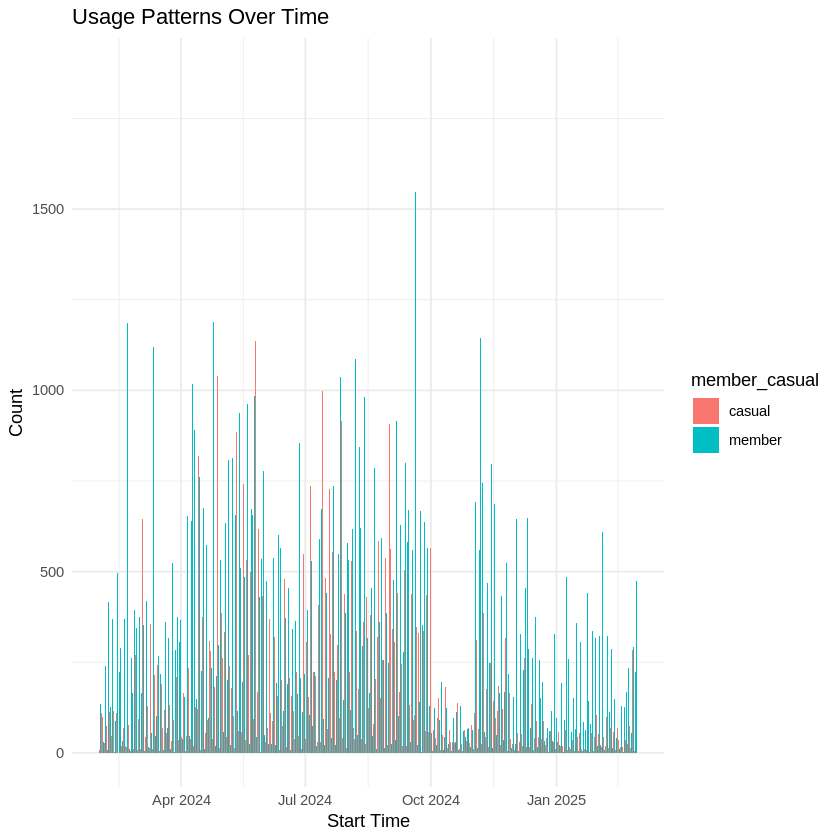

In [68]:
library(ggplot2)

# Visualize the usage patterns over time

ggplot(Divvy_24_25, aes(x = started_at, fill = member_casual)) +
  geom_histogram(binwidth = 3600, position = "dodge") +
  labs(title = "Usage Patterns Over Time", x = "Start Time", y = "Count") +
  theme_minimal()

# Calculate the number of trips per user type

In [69]:
trip_counts <- Divvy_24_25[, .N, by = .(member_casual)]
print(trip_counts)

   member_casual       N
          <char>   <int>
1:        member 2836078
2:        casual 1494089


# Calculate average trip duration per user type


In [70]:
avg_trip_duration <- Divvy_24_25[, .(avg_duration = mean(trip_duration, na.rm = TRUE)), by = .(member_casual)]
print(avg_trip_duration)

   member_casual avg_duration
          <char>        <num>
1:        member     12.40791
2:        casual     24.32311


# Identify peak usage times

In [71]:
Divvy_24_25[, hour_of_day := hour(started_at)]
peak_usage <- Divvy_24_25[, .N, by = .(member_casual, hour_of_day)]
print(peak_usage)

    member_casual hour_of_day      N
           <char>       <int>  <int>
 1:        member          14 158178
 2:        member          21  85722
 3:        member          15 194138
 4:        member          12 157930
 5:        casual          12  99519
 6:        member           0  23972
 7:        member           7 156766
 8:        member           9 134229
 9:        member           8 197896
10:        member          19 160737
11:        member          16 265392
12:        member          17 300344
13:        member          18 230245
14:        member           2   8157
15:        casual          19  88008
16:        member          13 157845
17:        casual          13 103351
18:        member          10 118299
19:        casual          11  83843
20:        casual          17 142766
21:        casual          15 119238
22:        member           6  82020
23:        member          20 111805
24:        member          11 138082
25:        casual          18 119981
2

# Visualize trip counts by user type

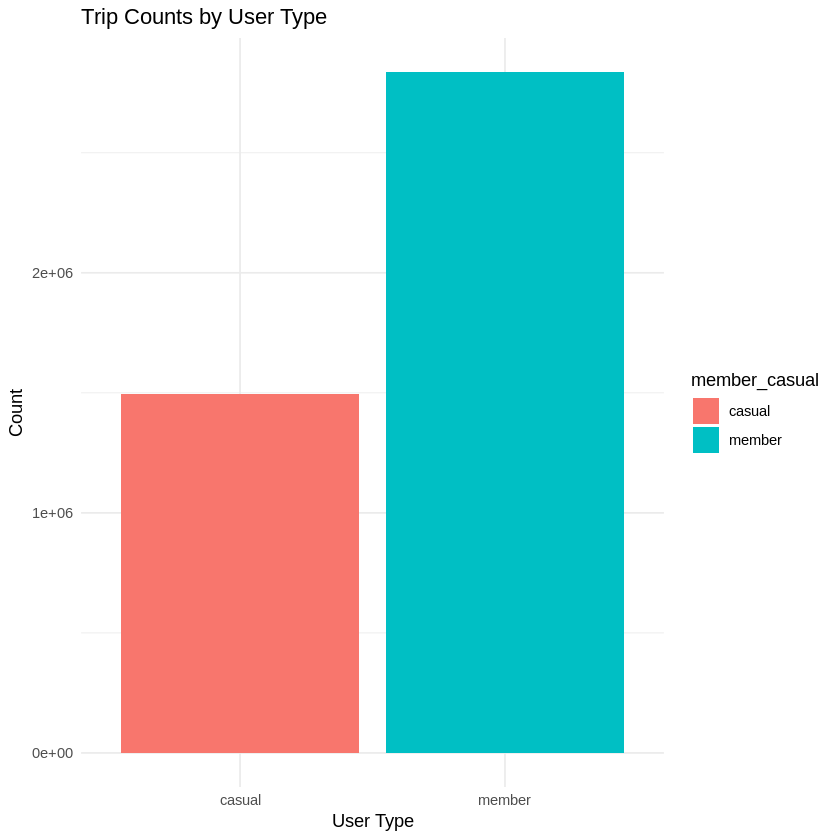

In [72]:
ggplot(trip_counts, aes(x = member_casual, y = N, fill = member_casual)) +
  geom_bar(stat = "identity") +
  labs(title = "Trip Counts by User Type", x = "User Type", y = "Count") +
  theme_minimal()

# Visualize average trip duration by user type

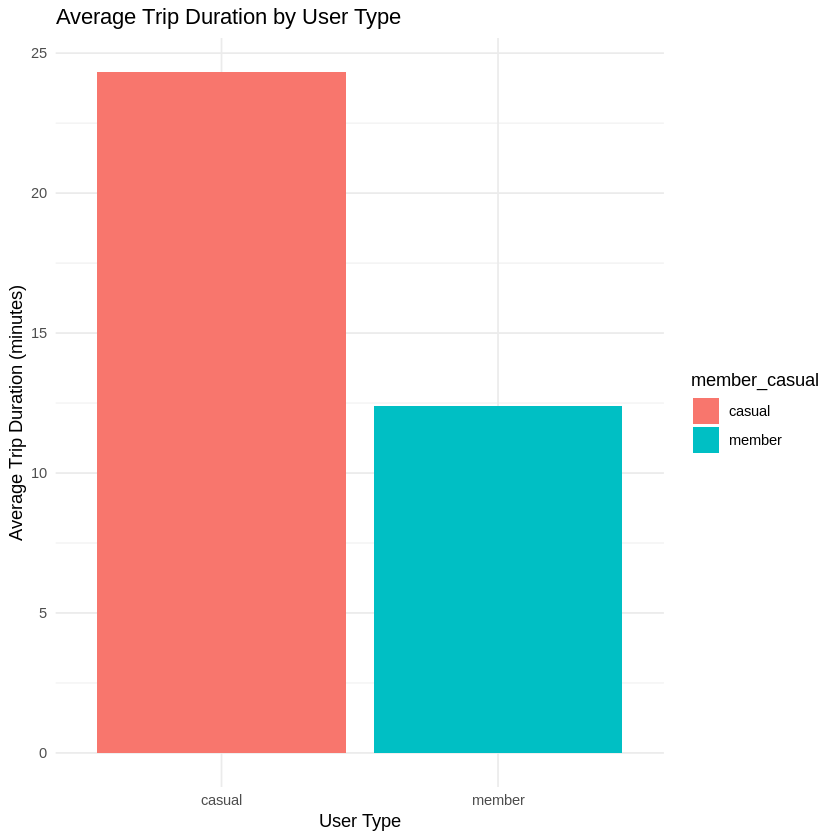

In [73]:
ggplot(avg_trip_duration, aes(x = member_casual, y = avg_duration, fill = member_casual)) +
  geom_bar(stat = "identity") +
  labs(title = "Average Trip Duration by User Type", x = "User Type", y = "Average Trip Duration (minutes)") +
  theme_minimal()

# Visualize peak usage times

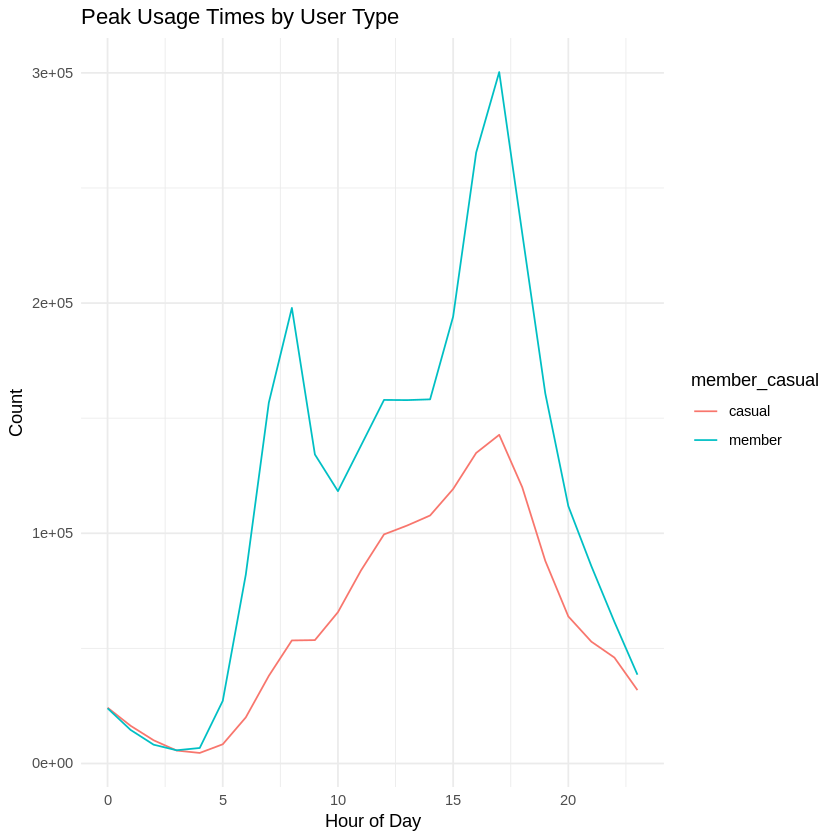

In [74]:
ggplot(peak_usage, aes(x = hour_of_day, y = N, color = member_casual, group = member_casual)) +
  geom_line() +
  labs(title = "Peak Usage Times by User Type", x = "Hour of Day", y = "Count") +
  theme_minimal()

# Perform a t-test to compare trip durations between members and casual riders

In [75]:
t_test_result <- t.test(trip_duration ~ member_casual, data = Divvy_24_25)
print(t_test_result)


	Welch Two Sample t-test

data:  trip_duration by member_casual
t = 170.33, df = 1743183, p-value < 2.2e-16
alternative hypothesis: true difference in means between group casual and group member is not equal to 0
95 percent confidence interval:
 11.77809 12.05231
sample estimates:
mean in group casual mean in group member 
            24.32311             12.40791 



# Function to calculate distance using the Haversine formula

In [76]:
haversine <- function(lat1, lon1, lat2, lon2) {
  R <- 3959 # Earth radius in miles
  delta_lat <- (lat2 - lat1) * pi / 180
  delta_lon <- (lon2 - lon1) * pi / 180
  a <- sin(delta_lat / 2) * sin(delta_lat / 2) +
    cos(lat1 * pi / 180) * cos(lat2 * pi / 180) *
    sin(delta_lon / 2) * sin(delta_lon / 2)
  c <- 2 * atan2(sqrt(a), sqrt(1 - a))
  R * c
}



# Calculate distance for each trip

> Add blockquote



In [77]:
Divvy_24_25[, distance := haversine(start_lat, start_lng, end_lat, end_lng)]

# Aggregate the data by binning trip duration and distance

In [78]:
library(dplyr)


binned_data <- Divvy_24_25 %>%
  mutate(
    trip_duration_bin = cut(trip_duration, breaks = seq(0, max(trip_duration, na.rm = TRUE), by = 5)),
    distance_bin = cut(distance, breaks = seq(0, max(distance, na.rm = TRUE), by = 0.5))
  ) %>%
  group_by(member_casual, trip_duration_bin, distance_bin) %>%
  dplyr::summarise(
       avg_trip_duration = mean(trip_duration, na.rm = TRUE),
       avg_distance = mean(distance, na.rm = TRUE),
       count = dplyr::n()
   ) %>%
  ungroup()

`summarise()` has grouped output by 'member_casual', 'trip_duration_bin'. You
can override using the `.groups` argument.


# Calculate the 10th and 90th percentiles for trip duration and distance

In [79]:
trip_duration_cutoffs <- quantile(Divvy_24_25$trip_duration, probs = c(0.1, 0.9), na.rm = TRUE)
distance_cutoffs <- quantile(Divvy_24_25$distance, probs = c(0.1, 0.9), na.rm = TRUE)

# Filter the data to remove the top and bottom 10%

In [80]:
filtered_data <- Divvy_24_25 %>%
  filter(trip_duration >= trip_duration_cutoffs[1], trip_duration <= trip_duration_cutoffs[2],
         distance >= distance_cutoffs[1], distance <= distance_cutoffs[2])

# Sample 10% of the filtered data
set.seed(123) # for reproducibility
sampled_data <- filtered_data %>% sample_frac(0.1)

# Create a box plot to visualize the distribution of trip durations by user type

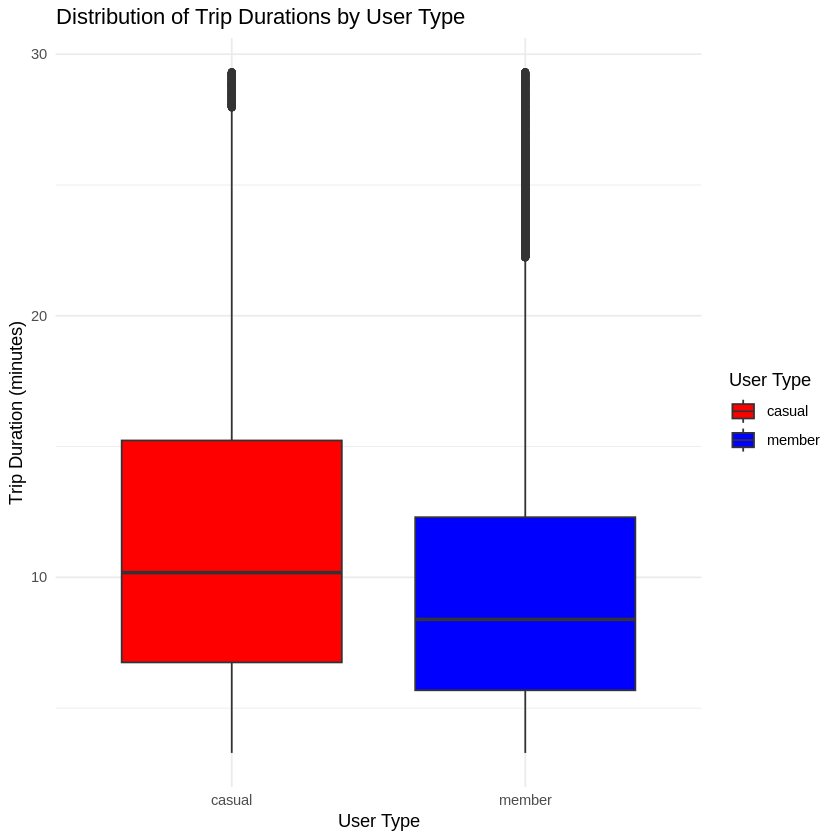

In [81]:
ggplot(sampled_data, aes(x = member_casual, y = trip_duration, fill = member_casual)) +
  geom_boxplot() +
  labs(
    title = "Distribution of Trip Durations by User Type",
    x = "User Type",
    y = "Trip Duration (minutes)",
    fill = "User Type"
  ) +
  scale_fill_manual(values = c("member" = "blue", "casual" = "red")) +
  theme_minimal()


# Create a histogram to show the distribution of trip durations by user type

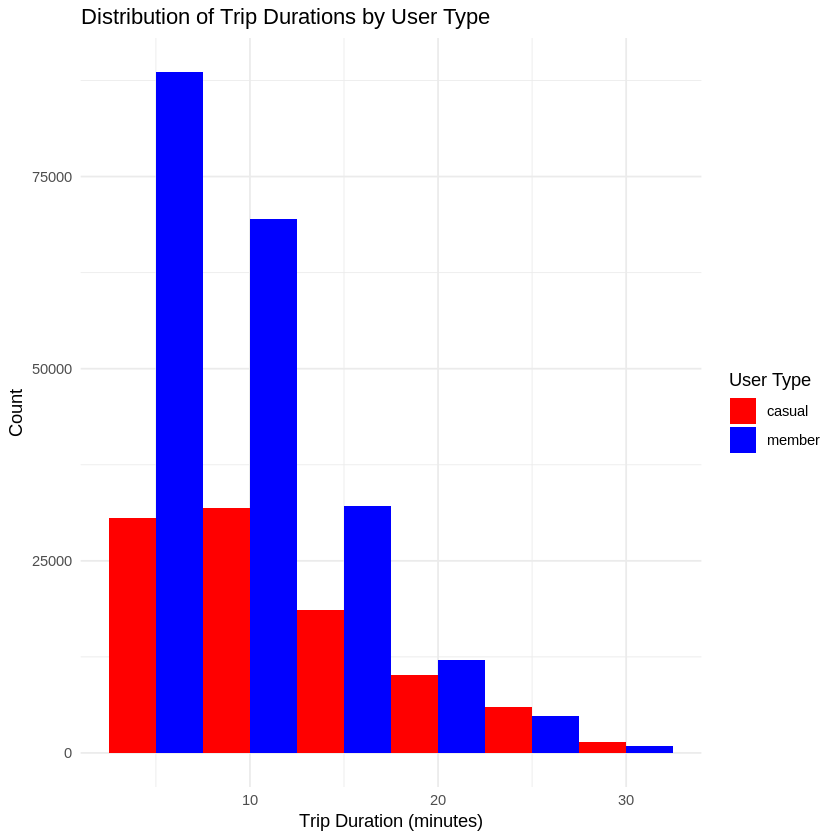

In [82]:
ggplot(sampled_data, aes(x = trip_duration, fill = member_casual)) +
  geom_histogram(binwidth = 5, position = "dodge") +
  labs(
    title = "Distribution of Trip Durations by User Type",
    x = "Trip Duration (minutes)",
    y = "Count",
    fill = "User Type"
  ) +
  scale_fill_manual(values = c("member" = "blue", "casual" = "red")) +
  theme_minimal()


# Create a density plot to show the distribution of trip durations by user type

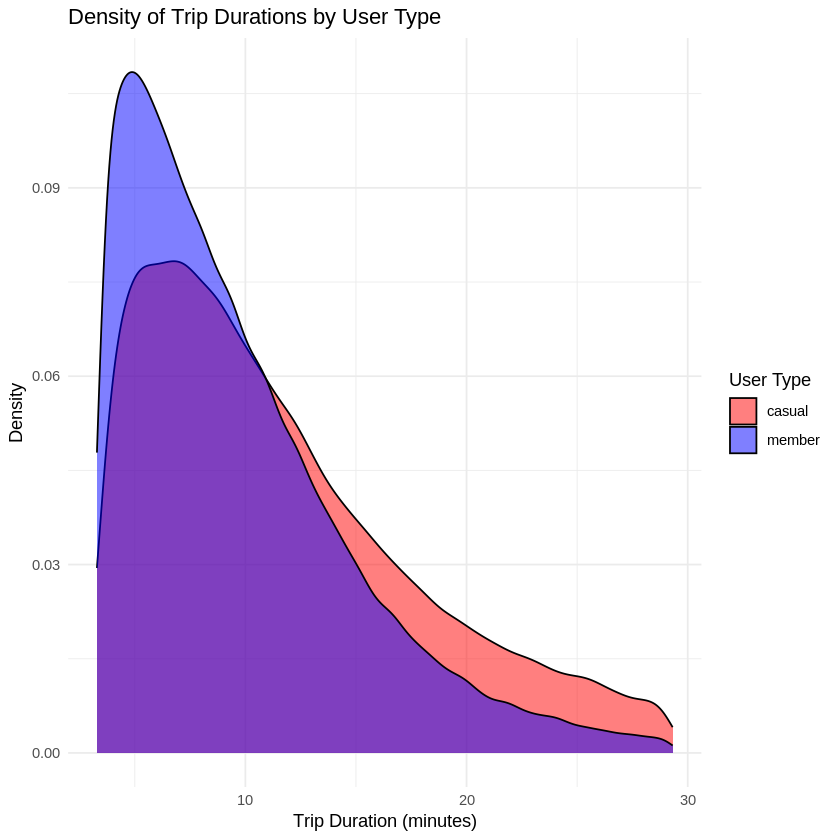

In [83]:
ggplot(sampled_data, aes(x = trip_duration, fill = member_casual)) +
  geom_density(alpha = 0.5) +
  labs(
    title = "Density of Trip Durations by User Type",
    x = "Trip Duration (minutes)",
    y = "Density",
    fill = "User Type"
  ) +
  scale_fill_manual(values = c("member" = "blue", "casual" = "red")) +
  theme_minimal()

# Analyze start station usage

In [84]:


start_station_usage <- Divvy_24_25[, .N, by = .(member_casual, start_station_name)]

# Find the top 10 start stations for each user type

top_start_stations <- start_station_usage[ , head(.SD, 10), by = member_casual][order(-N), ]

print("Top 10 Start Stations by User Type:")

print(top_start_stations)

[1] "Top 10 Start Stations by User Type:"
    member_casual             start_station_name     N
           <char>                         <char> <int>
 1:        member   Michigan Ave & Washington St 10673
 2:        member         Clark St & Schiller St  9162
 3:        member   Southport Ave & Waveland Ave  8596
 4:        member          Clark St & Newport St  7627
 5:        member      Franklin St & Chicago Ave  6443
 6:        casual      Desplaines St & Kinzie St  5575
 7:        member  Sangamon St & Washington Blvd  4333
 8:        casual     Franklin St & Jackson Blvd  4189
 9:        casual        Sedgwick St & North Ave  3639
10:        casual         Broadway & Belmont Ave  3446
11:        member     Sheridan Rd & Lawrence Ave  3324
12:        member      Leavitt St & Armitage Ave  3224
13:        casual Southport Ave & Wellington Ave  3105
14:        member         Benson Ave & Church St  2842
15:        casual      Franklin St & Chicago Ave  2769
16:        member  Mich

# Visualize top start stations

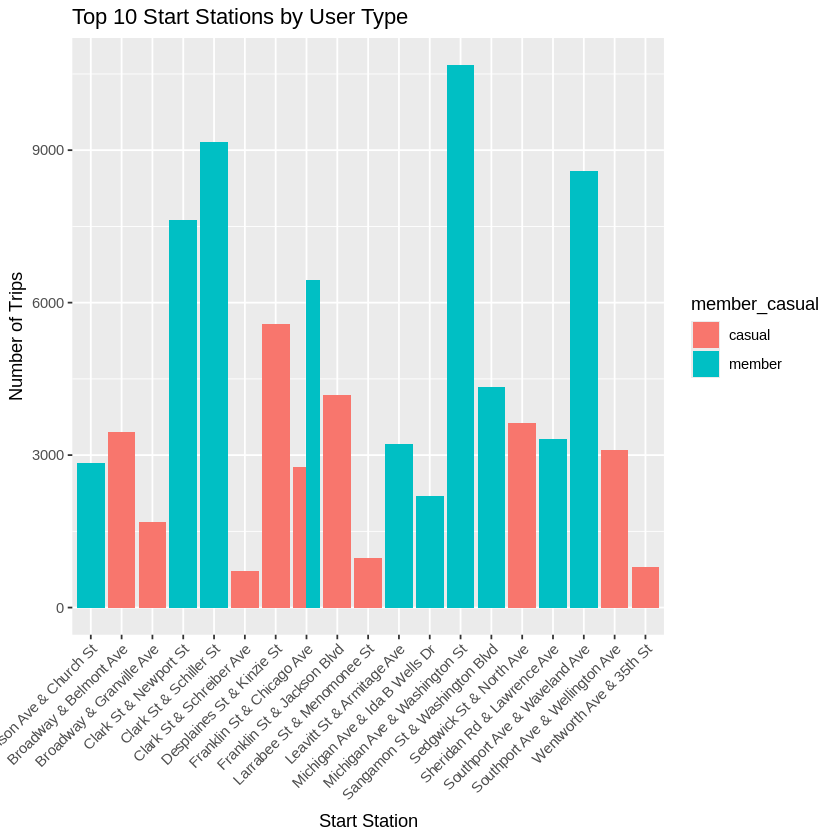

In [85]:
ggplot(top_start_stations, aes(x = start_station_name, y = N, fill = member_casual)) +

  geom_bar(stat = "identity", position = "dodge") +

  labs(title = "Top 10 Start Stations by User Type",

       x = "Start Station",

       y = "Number of Trips") +

  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # Rotate labels

In [86]:
# Analyze end station usage (similar to start station analysis)

end_station_usage <- Divvy_24_25[, .N, by = .(member_casual, end_station_name)]

# Find the top 10 end stations for each user type

top_end_stations <- end_station_usage[ , head(.SD, 10), by = member_casual][order(-N), ]

print("Top 10 End Stations by User Type:")

print(top_end_stations)


[1] "Top 10 End Stations by User Type:"
    member_casual                        end_station_name     N
           <char>                                  <char> <int>
 1:        member            Clinton St & Washington Blvd 23649
 2:        member                  Wabash Ave & Grand Ave 13732
 3:        member     Orleans St & Merchandise Mart Plaza 13728
 4:        casual                  Wabash Ave & Grand Ave 10400
 5:        member            Southport Ave & Waveland Ave  9530
 6:        member            Milwaukee Ave & Wabansia Ave  8162
 7:        casual                       Clark St & Elm St  7848
 8:        member                   Clark St & Newport St  7746
 9:        member                 Canal St & Jackson Blvd  7477
10:        member             Southport Ave & Belmont Ave  7207
11:        casual                  Clark St & Schiller St  5802
12:        casual                  St. Clair St & Erie St  4646
13:        member                 Sheridan Rd & Argyle St  3874


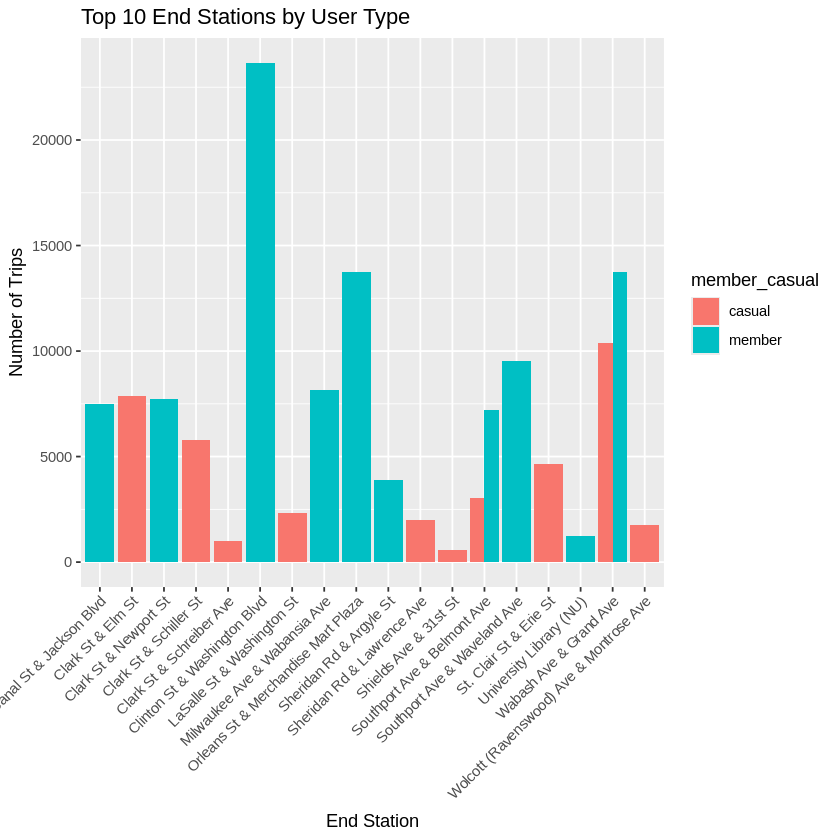

In [87]:
# Visualize top end stations (example)

ggplot(top_end_stations, aes(x = end_station_name, y = N, fill = member_casual)) +

  geom_bar(stat = "identity", position = "dodge") +

  labs(title = "Top 10 End Stations by User Type",

       x = "End Station",

       y = "Number of Trips") +

  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [88]:
install.packages("lubridate")
library(lubridate) # Make sure lubridate is loaded

# Add a column to indicate the day of the week
# Use lubridate::wday explicitly to avoid conflicts with data.table::wday
Divvy_24_25[, day_of_week := lubridate::wday(started_at, label = TRUE)]  # Use label = TRUE for abbreviated day names

# Analyze trip counts by day of week and user type

usage_by_day <- Divvy_24_25[, .N, by = .(member_casual, day_of_week)]

print("Usage by Day of Week:")

print(usage_by_day)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Usage by Day of Week:"
    member_casual day_of_week      N
           <char>       <ord>  <int>
 1:        member         Sat 363812
 2:        member         Mon 416861
 3:        member         Thu 433889
 4:        casual         Wed 186797
 5:        member         Fri 411402
 6:        member         Sun 312367
 7:        member         Tue 439972
 8:        member         Wed 457775
 9:        casual         Mon 180246
10:        casual         Thu 182370
11:        casual         Tue 163920
12:        casual         Sun 249381
13:        casual         Sat 309329
14:        casual         Fri 222046


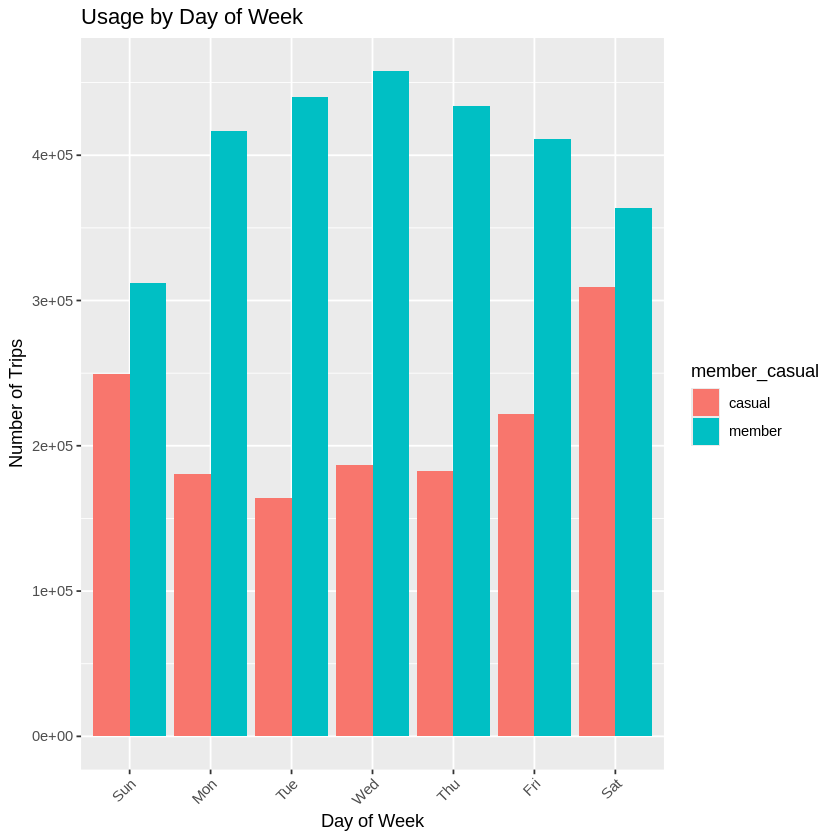

In [89]:
# Visualize usage by day of week


ggplot(usage_by_day, aes(x = day_of_week, y = N, fill = member_casual)) +

  geom_bar(stat = "identity", position = "dodge") +

  labs(title = "Usage by Day of Week",

       x = "Day of Week",

       y = "Number of Trips") +

  theme(axis.text.x = element_text(angle = 45, hjust = 1))

[1] "Usage by Day of Week:"
    member_casual day_of_week      N
           <char>       <ord>  <int>
 1:        member         Sat 363812
 2:        member         Mon 416861
 3:        member         Thu 433889
 4:        casual         Wed 186797
 5:        member         Fri 411402
 6:        member         Sun 312367
 7:        member         Tue 439972
 8:        member         Wed 457775
 9:        casual         Mon 180246
10:        casual         Thu 182370
11:        casual         Tue 163920
12:        casual         Sun 249381
13:        casual         Sat 309329
14:        casual         Fri 222046


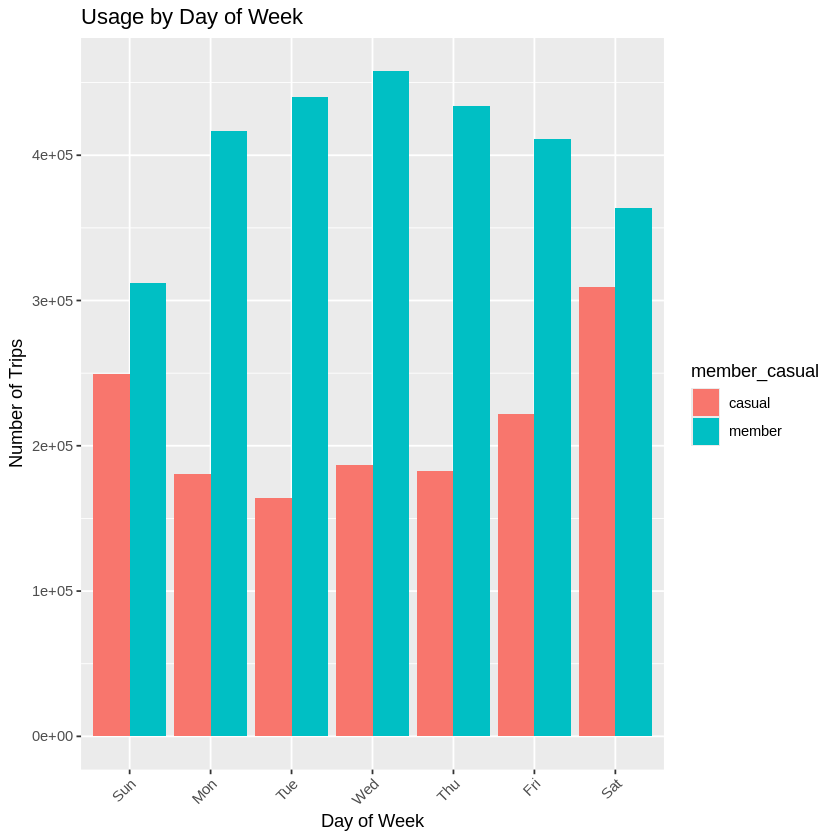

In [90]:
Divvy_24_25[, day_of_week := lubridate::wday(started_at, label = TRUE, abbr = TRUE)]  # Use lubridate::wday and label = TRUE for abbreviated day names

# Analyze trip counts by day of week and user type

usage_by_day <- Divvy_24_25[, .N, by = .(member_casual, day_of_week)]

print("Usage by Day of Week:")

print(usage_by_day)

# Visualize usage by day of week (example)

ggplot(usage_by_day, aes(x = day_of_week, y = N, fill = member_casual)) +

  geom_bar(stat = "identity", position = "dodge") +

  labs(title = "Usage by Day of Week",

       x = "Day of Week",

       y = "Number of Trips") +

  theme(axis.text.x = element_text(angle = 45, hjust = 1))

[1] "Usage by Month:"
    member_casual  month      N
           <char> <char>  <int>
 1:        member    Feb 300120
 2:        casual    Feb  74909
 3:        member    Mar 219137
 4:        casual    Mar  82550
 5:        member    Apr 283215
 6:        casual    Apr 131810
 7:        casual    May 231052
 8:        member    May 378503
 9:        casual    Jun 123305
10:        member    Jun 175147
11:        casual    Jul 234778
12:        member    Jul 315428
13:        member    Aug 311532
14:        casual    Aug 215120
15:        member    Sep 305365
16:        casual    Sep 208462
17:        member    Oct  51118
18:        casual    Oct  36511
19:        member    Nov 241980
20:        casual    Nov  93062
21:        member    Dec 140006
22:        casual    Dec  38406
23:        member    Jan 114527
24:        casual    Jan  24124
    member_casual  month      N


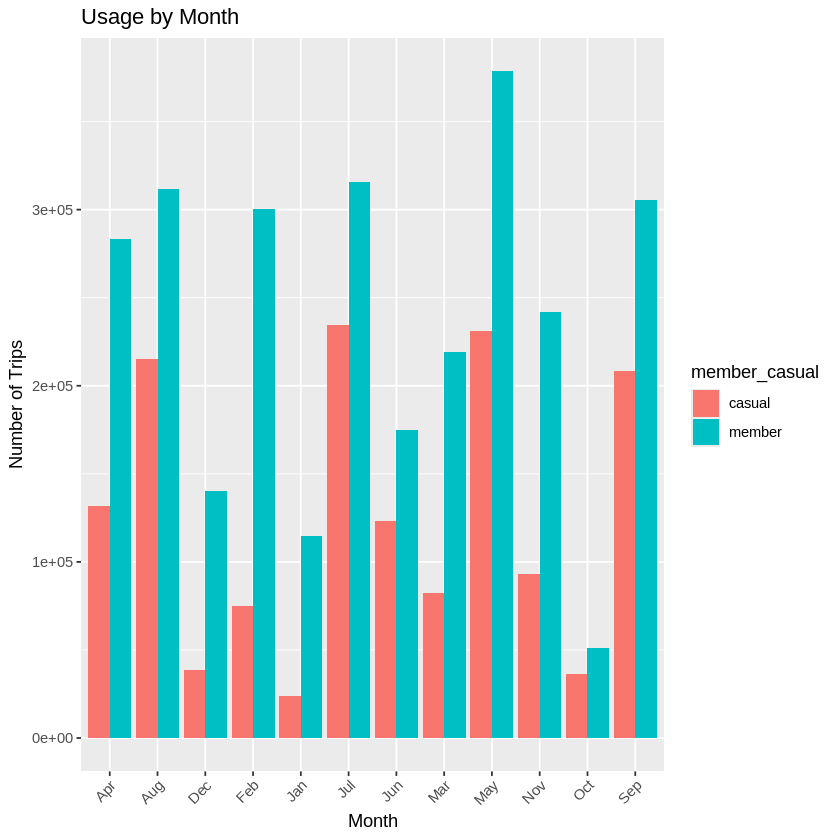

In [91]:
# Add a column to indicate the month

# Add a column to indicate the month using the format() function
Divvy_24_25[, month := format(started_at, "%b")] # Use format with %b for abbreviated month names

# Analyze trip counts by month and user type

usage_by_month <- Divvy_24_25[, .N, by = .(member_casual, month)]

print("Usage by Month:")

print(usage_by_month)

# Visualize usage by month (example)

ggplot(usage_by_month, aes(x = month, y = N, fill = member_casual)) +

  geom_bar(stat = "identity", position = "dodge") +

  labs(title = "Usage by Month",

       x = "Month",

       y = "Number of Trips") +

  theme(axis.text.x = element_text(angle = 45, hjust = 1))
